# Flowline: comparing front treatments (HO)

A marine-terminating glacier along a flowline: grounded on a bed that deepens toward the sea, crossing sea level, and ungrounding into a floating tongue. (1) It is first spun up for 100 years with a nonmoving front, to a steady state. From there, it is run for 20 years in three ways: (2) moving front without calving, (3) moving front with a rate law (calving proportional to the submerged thickness), and (4) moving front with a position law (floating ice stretching faster than 0.002 a⁻¹ calves). The tongue melts at its base at 10 m/a throughout.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from model import model
from issm_helper import *

## Geometry and parameters

Nodes every 250 m along a 50 km flowline. The bed falls from 100 m at a slope of 1.25%, crossing sea level at 8 km. The ice thins from 500 m at the inflow to 200 m at the terminus (30 km) and floats beyond 25.5 km. Friction weakens toward the sea, with C proportional to the initial thickness to the power 2/3, so that the sliding flux is roughly the same along the glacier; ice enters at x = 0 at 240 m/a, matching it.

In [2]:
x_nodes = np.arange(0, 50e3 + 1, 250) #node positions along the flowline (m)
md = flowline_mesh(model(), x_nodes)
x = md.mesh.x

x_t = 30e3 #initial terminus position (m)
bed = 100 - 0.0125*x #from 100 m to -525 m
H_0 = 500 + (200 - 500)*x/x_t #from 500 m at the inflow to 200 m at the terminus

initialization_params = {'approximation': 'HO',
                         'vertical_layers': 5,
                         'temperature': 263.15,
                         'friction': 2200*(H_0/500)**(2/3), #Weertman C
                         'basal_melt': 10, #under floating ice (m/a)
                         'bed': bed,
                         'thickness': H_0,
                         'ice_levelset': x - x_t,
                         'spcvx': dirichlet(md, (x == 0, 240)),
                         'spcthickness': dirichlet(md, (x == 0, H_0))}

Δt = 0.5 #time step (a)
model_time = 20 #years
num_steps = int(model_time/Δt)

Δt_spinup = 1.0
spinup_time = 100 
spinup_steps = int(spinup_time/Δt_spinup)

### (1) Spin-up with a nonmoving front

100 years in yearly steps, all in one call; the glacier is steady after about 90.

In [3]:
md1 = flowline_mesh(model(), x_nodes)
md1 = initialize_model(md1, moving_front = False, **initialization_params)

u, H_spinup, s = coupled_solve(md1, Δt_spinup, num_steps = spinup_steps) 

Each of the runs below starts from a new model with the spun-up thickness and a moving front.

In [4]:
spinup_params = {**initialization_params, 'thickness': H_spinup}

### (2) Moving front, no calving

In [5]:
md2 = flowline_mesh(model(), x_nodes)
md2 = initialize_model(md2, moving_front = True, **spinup_params)

for step in tqdm.trange(num_steps):
    u, H, s = coupled_solve(md2, Δt)

100%|██████████| 40/40 [00:38<00:00,  1.05it/s]


### (3) Moving front, rate law: calving proportional to the submerged thickness

The calving rate is c·d, with d the submerged thickness: the depth of the ice base below sea level. Once the tongue is gone, d is the water depth at a grounded front, so on this bed the front retreats into shallower water, where calving slows.

In [6]:
c = 2 #calving rate per metre of submerged thickness (1/a)

md3 = flowline_mesh(model(), x_nodes)
md3 = initialize_model(md3, moving_front = True, **spinup_params)

for step in tqdm.trange(num_steps):
    u = diagnostic_solve(md3)
    d = np.maximum(-md3.geometry.base, 0) #submerged thickness (m), sea level at 0
    rate_law(md3, rate = c*d, extrapolate = True)
    H, s = prognostic_solve(md3, Δt)

100%|██████████| 40/40 [00:25<00:00,  1.54it/s]


### (4) Moving front, position law: floating ice stretching faster than $\varepsilon_c$ a⁻¹ calves

Calving starts at the front and spreads upstream through floating ice above the threshold. In a flowline, the tensile strain rate is the along-flow strain rate du/dx, where positive. It is taken from the velocity at ice nodes only, because ISSM's nodal strain rate at the front is distorted by the ice-free node next to it. Only floating ice can calve: the grounded glacier stretches faster than its tongue and would calve too. A freely floating tongue stretches at a rate set by its thickness (proportional to H³), fastest at the grounding line, so once its front exceeds the threshold, the whole tongue does.

In [7]:
ε_c = 0.001 #tensile strain rate above which floating ice calves (1/a)

md4 = flowline_mesh(model(), x_nodes)
md4 = initialize_model(md4, moving_front = True, **spinup_params)

for step in tqdm.trange(num_steps):
    u = diagnostic_solve(md4)
    x_p, u_p = profile(md4, u[0]) #surface velocity along the flowline
    ice = profile(md4, md4.mask.ice_levelset)[1] < 0
    ε_1 = np.maximum(np.gradient(u_p[ice], x_p[ice]), 0) #tensile strain rate along the ice (1/a)
    ε_1 = np.interp(md4.mesh.x, x_p[ice], ε_1) #on every node
    floating = md4.mask.ocean_levelset < 0
    position_law(md4, forcing = np.where(floating, ε_1, 0), threshold = ε_c)
    H, s = prognostic_solve(md4, Δt)

100%|██████████| 40/40 [00:48<00:00,  1.21s/it]


## Comparison

The spun-up glacier, and the three runs 20 years later, with the surface speed in red (right axis). The dashed line is the terminus, the triangle the grounding line, and the dotted line the initial terminus.

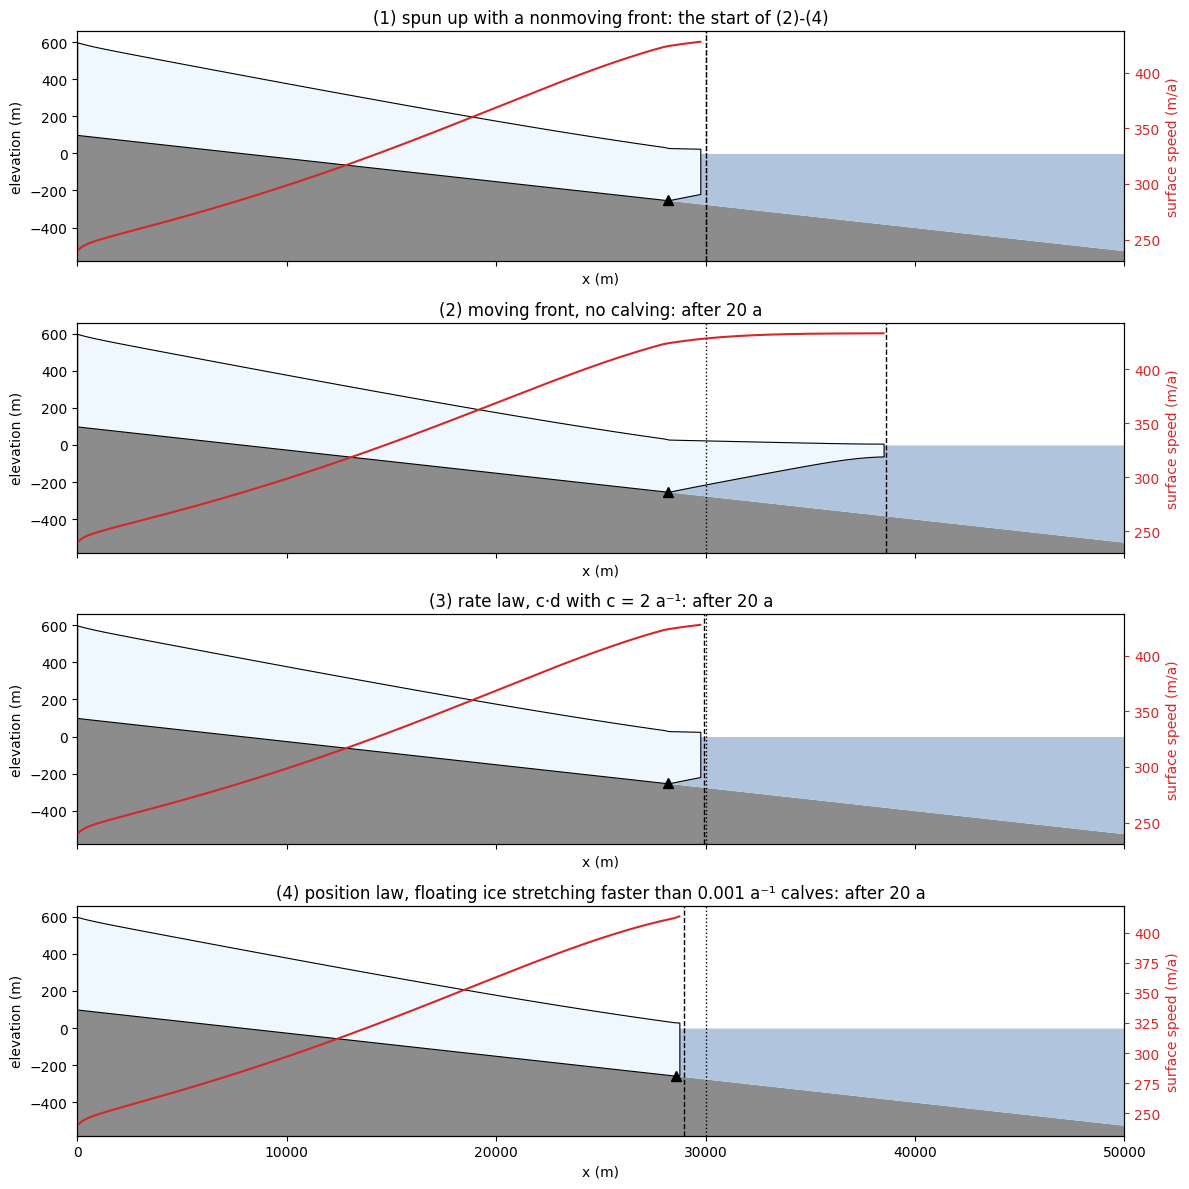

In [8]:
fig, axes = plt.subplots(4, 1, figsize = (12, 12), sharex = True)
for ax, (title, md) in zip(axes, [('(1) spun up with a nonmoving front: the start of (2)-(4)', md1),
                                  ('(2) moving front, no calving: after 20 a', md2),
                                  (f'(3) rate law, c·d with c = {c} a⁻¹: after 20 a', md3),
                                  (f'(4) position law, floating ice stretching faster than {ε_c} a⁻¹ calves: after 20 a', md4)]):
    plot_geometry(md, ax = ax, title = title)
    ax.axvline(x_t, color = 'k', linestyle = 'dotted', linewidth = 1) #initial terminus

    x_p, speed = profile(md, np.hypot(md.initialization.vx, md.initialization.vy)) #surface speed (m/a)
    ice = profile(md, md.mask.ice_levelset)[1] < 0
    ax2 = ax.twinx()
    ax2.plot(x_p, np.where(ice, speed, np.nan), color = 'C3')
    # ax2.set_ylim(0, 800)
    ax2.set_ylabel('surface speed (m/a)', color = 'C3')
    ax2.tick_params(axis = 'y', colors = 'C3')
plt.tight_layout()
plt.show()